In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.preprocessing import StandardScaler
import os
import globals as gl
from pcm_cortical import find_model, make_planning_models, make_execution_models
import PcmPy as pcm
from scipy.stats import linregress, t, permutation_test
import pickle
import pingouin as pg

from scipy.stats import ttest_1samp, pearsonr, ttest_rel
from matplotlib.patches import ConnectionPatch, Rectangle, Patch
from matplotlib import colormaps as cm
from Plot import add_significant_patches_to_ml_rois, add_lineplot_to_boxplot, set_spines_and_ticks_width, add_noise_ceiling, save_figure_incremental

plt.style.use('default')
plt.style.use('dark_background')

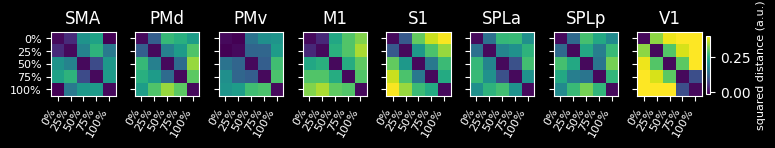

In [47]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.p'), 'component')
n_param = Mf.n_param

vmin, vmax = -.01, .4

fig, axs = plt.subplots(1, len(rois), figsize=(7, 2),sharex=True, sharey=True, constrained_layout=True)

for r, roi in enumerate(rois):

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy')).mean(axis=0)
    D_obs = pcm.G_to_dist(G_obs)
    D_obs = np.sign(D_obs) * np.sqrt(np.abs(D_obs))

    # Top row: imshow
    im_ax = axs[r]
    cax = im_ax.imshow(D_obs, vmin=vmin, vmax=vmax)
    im_ax.set_xticks(np.arange(5))
    im_ax.set_xticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8, rotation=60, ha='right')
    im_ax.set_title(roi)
    # if r==0:
    im_ax.set_yticks(np.arange(5))
    im_ax.set_yticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8)

bbox = axs[0,].get_position()
cbar_ax = fig.add_axes([1, bbox.y0, 0.006, bbox.y1 - bbox.y0])
fig.colorbar(cax, cax=cbar_ax).set_label('squared distance (a.u.)', fontsize=8)

plt.show()

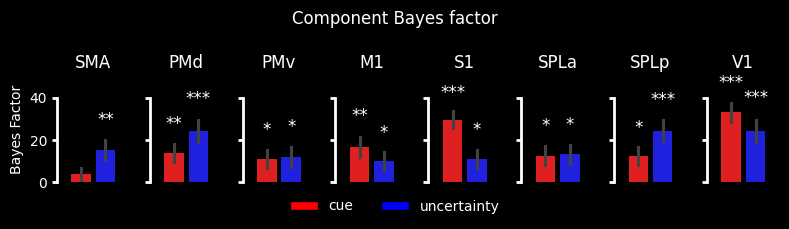

In [48]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

M = make_planning_models()
M, _ = find_model(M, 'component')
G = M.Gc
MF = pcm.model.ModelFamily(G, comp_names=['cue', 'uncertainty'], basecomponents=None)

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2), sharex=True, sharey=True, constrained_layout=True)

for r, roi in enumerate(rois):
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.plan.glm{glm}.{H}.{roi}.p'))
    plt.sca(axs[r])
    c_bf = MF.component_bayesfactor(T.likelihood,method='AIC',format='DataFrame')
    bars = pcm.vis.plot_component(c_bf, type='bf', palette=['red', 'blue'],errorbar='se')

    for i, col in enumerate(c_bf.columns):
        vals = c_bf[col].dropna().values
        vals = vals[np.isfinite(vals)]
        n = len(vals)
        if n < 2:
            continue

        _, p_val_1samp = ttest_1samp(vals, 0)

        mean = vals.mean()
        sem = vals.std(ddof=1) / (n**0.5)
        ci = t.ppf(0.975, df=n-1) * sem  # 95% CI
        bar_height = mean + ci

        if p_val_1samp < 0.001:
            stars = '***'
        elif p_val_1samp < 0.01:
            stars = '**'
        elif p_val_1samp < 0.05:
            stars = '*'
        else:
            stars = None

        if stars:
            axs[r].text(i, bar_height, stars, ha='center', va='bottom', fontsize=12)

    axs[r].spines[['bottom', 'left',]].set_linewidth(2)
    axs[r].spines[['left',]].set_bounds([0, 40])
    axs[r].tick_params(width=2)
    axs[r].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    axs[r].spines[['top', 'right','bottom']].set_visible(False)
    axs[r].set_xlabel('')
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(axs[r].get_xticklabels(), rotation=60, ha='right')
    axs[r].set_title(roi)

for r in range(len(rois)):
    # axs[r].set_yscale('symlog')
    axs[r].set_ylim([0, 50])
    axs[r].set_xlim([-1, 2])

fig.suptitle('Component Bayes factor')


# Define legend handles
legend_handles = [
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='blue', edgecolor='black', label='uncertainty')
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=False,
           ncol=2,
           fontsize=10)

fig.tight_layout()
plt.show()

In [ ]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

features = np.array(['cue', 'uncertainty'])

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.p'), 'component')
n_param = Mf.n_param

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)

for r, roi in enumerate(rois):

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    tr = np.array([np.trace(G) for G in G_obs])
    tr_mean = np.sqrt(tr.mean())
    tr_err = np.sqrt(tr.std()) / np.sqrt(len(tr))

    # Bottom row: bar plot
    ax = axs[r]
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    params = pickle.load(f)[idx]
    theta = params[:n_param]
    theta_exp = np.exp(theta)
    theta_sqrt = np.sqrt(theta_exp)

    df = pd.DataFrame(theta_sqrt.T, columns=features)

    sns.barplot(data=df, ax=ax, palette=['red', 'blue'], errorbar='se')
    ax.set_xticks([])
    ax.axhline(tr_mean, color='grey', lw=2, ls=':')
    ax.axhspan(tr_mean - tr_err,
                   tr_mean + tr_err, color='grey', alpha=.2, lw=0)
    ax.set_title(roi)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.set_xlim((-1, 2))
    ax.tick_params(width=2)
    ax.set_ylabel('variance')
    ax.set_yticks((0, .3, .6))
    ax.spines[['left',]].set_bounds(0, .6)
    if r == 0:
        ax.spines[['left',]].set_linewidth(2)
    else:
        ax.spines[['top', 'right','bottom']].set_visible(False)
        ax.spines[['left',]].set_linewidth(2)

    a = df['cue']
    b = df['uncertainty']

    _, p_val_paired = ttest_rel(a, b)

    # Significance stars
    if p_val_paired < 0.001:
        stars = '***'
    elif p_val_paired < 0.01:
        stars = '**'
    elif p_val_paired < 0.05:
        stars = '*'
    else:
        stars = None

    if stars:
        # Estimate max height for the bar
        y_max = np.max((a.mean() + a.std() / np.sqrt(len(a)),(b.mean() + b.std() / np.sqrt(len(b)))))

        # Compute x positions of the bars for the two models
        center = .5
        x1 = center - .4   # component
        x2 = center + .4   # feature

        # Draw bar and stars
        ax.plot([x1, x2], [y_max + .1 * y_max, y_max+ .1 * y_max], lw=1.5, c='w')
        ax.text(.5, y_max + .1 * y_max, stars, ha='center', va='bottom', fontsize=12)

fig.suptitle('Variance explained by component model')

# Define legend handles
legend_handles = [
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='blue', edgecolor='black', label='uncertainty')
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=False,
           ncol=2,
           fontsize=10)

fig.tight_layout()
plt.show()

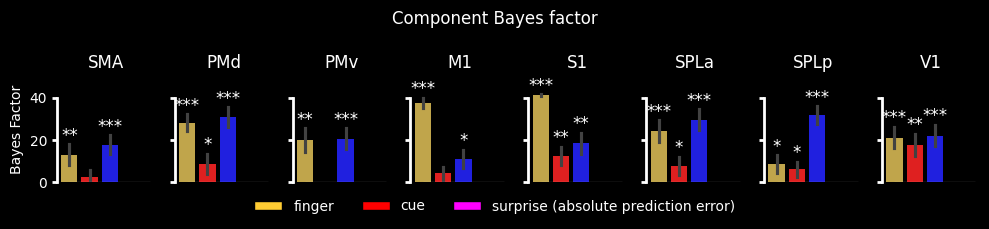

In [15]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

components = ['finger', 'cue', 'surprise']

M = make_execution_models()
M, _ = find_model(M, 'feature')
MF = pcm.model.ModelFamily(M, comp_names=components,)

fig, axs = plt.subplots(1, len(rois), figsize=(10, 2),  constrained_layout=True, sharey=True)

for r, roi in enumerate(rois):
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.exec.glm{glm}.{H}.{roi}.p'))
    plt.sca(axs[r])
    c_bf = MF.component_bayesfactor(T.likelihood,method='AIC',format='DataFrame')
    bars = pcm.vis.plot_component(c_bf, type='bf',palette=['#D4AF37', 'red', 'blue', 'magenta'], errorbar='se')

    for i, col in enumerate(c_bf.columns):
        vals = c_bf[col].dropna().values
        vals = vals[np.isfinite(vals)]
        n = len(vals)
        if n < 2:
            continue

        _, p_val_1samp = ttest_1samp(vals, 0, alternative='greater')

        mean = vals.mean()
        sem = vals.std() / np.sqrt(len(vals))
        bar_height = mean + sem

        if p_val_1samp < 0.001:
            stars = '***'
        elif p_val_1samp < 0.01:
            stars = '**'
        elif p_val_1samp < 0.05:
            stars = '*'
        else:
            stars = None

        if stars:
            axs[r].text(i, bar_height, stars, ha='center', va='bottom', fontsize=12)

    axs[r].set_title(roi)
    axs[r].set_xlabel('')
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(components, rotation=60, ha='right')
    axs[r].hlines(0, 0, 4, color='w', lw=0.8)
    axs[r].spines[['top', 'right', 'bottom']].set_visible(False)
    axs[r].spines[['left', ]].set_bounds(0, 40)
    axs[r].spines[['left', ]].set_linewidth(2)
    axs[r].set_ylim([0, 50])
    axs[r].spines[['bottom',]].set_bounds(0, 5)
    axs[r].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    axs[r].tick_params(width=2)

# Define legend handles
legend_handles = [
    Patch(facecolor='#FFCC33', edgecolor='black', label='finger'),
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='magenta', edgecolor='black', label='surprise (absolute prediction error)'),
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=False,
           ncol=6,
           fontsize=10)

fig.suptitle('Component Bayes factor')

fig.tight_layout()

plt.show()

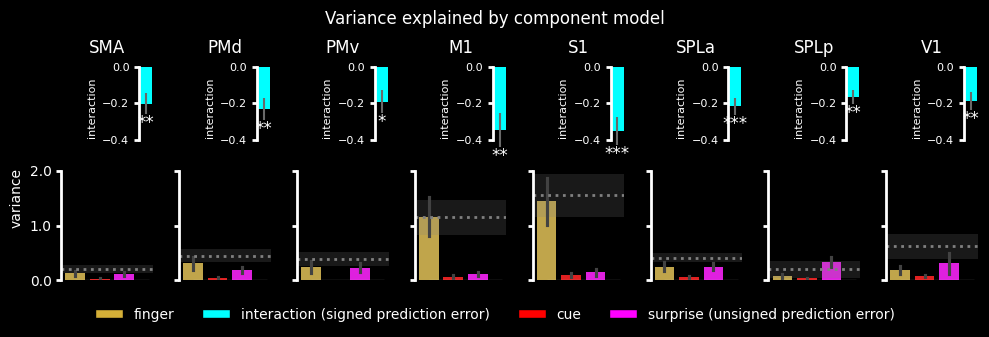

In [13]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

components = np.array(['finger', 'cue', 'surprise'])

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.p'), 'component')
n_param_c = Mc.n_param

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.p'), 'feature')
n_param_f = Mf.n_param

fig, axs = plt.subplots(1, len(rois), figsize=(10, 3), sharey=True, constrained_layout=True)

inset_axs = []

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    tr = np.array([np.trace(G) for G in G_obs])

    ax = axs[r]
    params = pickle.load(f)

    # variance explained
    params_c = params[idxc]
    theta_c = params_c[:n_param_c]
    var_expl = np.exp(theta_c)

    # interaction
    params_f = params[idxf]
    theta_f = params_f[:n_param_f]
    interaction = theta_f[1, :] * theta_f[2, :]

    # main axes
    sns.barplot(data=var_expl.T, ax=ax, palette=['#D4AF37', 'red', 'magenta'], errorbar='se')
    ax.set_title(roi, pad=10)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(components, rotation=60, ha='right')
    ax.hlines(0, 0, 3, color='w', lw=0.8)
    ax.axhline(tr.mean(), color='grey', lw=2, ls=':')
    ax.axhspan(tr.mean() - tr.std() / np.sqrt(len(tr)), tr.mean() + tr.std() / np.sqrt(len(tr)), color='grey', alpha=.2, lw=0)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.spines[['left', ]].set_bounds(0, 2)
    ax.spines[['left', ]].set_linewidth(2)
    ax.set_yticks([-.5, 0, 1, 2])
    ax.set_ylim((0, 3))
    ax.spines[['bottom',]].set_bounds(0, 4)
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.set_ylabel('variance')
    ax.tick_params(width=2)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)

    # inset for interaction
    inset_ax = ax.inset_axes([.85, .8, .15, .5], transform=ax.transAxes)
    interaction = theta_f[1,:] * theta_f[2,:]
    inset_ax.bar(0, interaction.mean(), width=.5, facecolor='cyan', yerr=interaction.std() / np.sqrt(len(interaction)), ecolor='dimgrey')
    inset_ax.spines[['top', 'right', 'bottom']].set_visible(False)
    inset_ax.spines[['left', ]].set_linewidth(2)
    inset_ax.spines[['left', ]].set_bounds(-.4, 0)
    inset_ax.set_ylabel('interaction', fontsize=8)
    inset_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    inset_ax.tick_params(axis='y', width=2, labelsize=8)
    inset_ax.set_ylim(-.45, 0)

    # t-test against zero for interaction
    _, p_val_1samp = ttest_1samp(interaction, 0, alternative='two-sided')

    n = len(interaction)
    mean = np.abs(interaction.mean())
    sem = interaction.std() / np.sqrt(len(interaction))
    bar_height = np.sign(interaction.mean()) * (mean + sem) * 1

    if p_val_1samp < 0.001:
        stars = '***'
    elif p_val_1samp < 0.01:
        stars = '**'
    elif p_val_1samp < 0.05:
        stars = '*'
    else:
        stars = 'ns'

    if stars:
        inset_ax.text(0, bar_height, stars, ha='center', va='top', fontsize=12)

    inset_axs.append(inset_ax)

# Define legend handles
legend_handles = [
    Patch(facecolor='#D4AF37', edgecolor='black', label='finger'),
    Patch(facecolor='cyan', edgecolor='black', label='interaction (signed prediction error)'),
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='magenta', edgecolor='black', label='surprise (unsigned prediction error)'),
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=False,
           ncol=6,
           fontsize=10)

fig.tight_layout()

fig.suptitle('Variance explained by component model')


plt.show()